# Week 9 — Exercise A (Node-level statistics)

We use the adjacency matrix from the exercise and solve:

1. **A.1 Eigenvector centrality** via $(A-\lambda_{\max}I)e=0$ for the largest eigenvalue.
2. **A.2 Clustering coefficient** via
   $c = (D(D-I))^{-1}\operatorname{diag}(A^3)$,
   i.e. node-wise $c_i = \frac{(A^3)_{ii}}{d_i(d_i-1)}$ (for $d_i>1$).

In [2]:
import numpy as np
import pandas as pd

# Adjacency matrix from the exercise statement
A = np.array([
    [0., 0., 1., 1., 0., 1., 0.],
    [0., 0., 0., 0., 1., 1., 1.],
    [1., 0., 0., 1., 0., 1., 0.],
    [1., 0., 1., 0., 0., 1., 0.],
    [0., 1., 0., 0., 0., 1., 1.],
    [1., 1., 1., 1., 1., 0., 1.],
    [0., 1., 0., 0., 1., 1., 0.],
])

n = A.shape[0]
nodes = np.arange(1, n + 1)
A

array([[0., 0., 1., 1., 0., 1., 0.],
       [0., 0., 0., 0., 1., 1., 1.],
       [1., 0., 0., 1., 0., 1., 0.],
       [1., 0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 1., 1.],
       [1., 1., 1., 1., 1., 0., 1.],
       [0., 1., 0., 0., 1., 1., 0.]])

In [5]:
# A.1 Eigenvector centrality: solve (A - lambda_max I)e = 0

# Largest eigenvalue (given ~3.646 in the sheet)
eigvals = np.linalg.eigvals(A)
lambda_max = eigvals.real.max()

M = A - lambda_max * np.eye(n)

# Null-space direction via SVD (right singular vector for smallest singular value)
_, _, vh = np.linalg.svd(M)
e = vh[-1, :].real

# Sign convention: make entries positive
if e.sum() < 0:
    e = -e

# Common normalizations
e_l1 = e / e.sum()                 # sum to 1
e_l2 = e / np.linalg.norm(e)       # Euclidean norm 1

ev_df = pd.DataFrame({
    'node': nodes,
    'eigenvector_centrality': e,
    'eigenvector_centrality_l1': e_l1,
    'eigenvector_centrality_l2': e_l2,
})

print(f'lambda_max = {lambda_max:.6f}')
ev_df.round(6)

lambda_max = 3.645751


,node,eigenvector_centrality,eigenvector_centrality_l1,eigenvector_centrality_l2
0,1,0.338866,0.130792,0.338866
1,2,0.338866,0.130792,0.338866
2,3,0.338866,0.130792,0.338866
3,4,0.338866,0.130792,0.338866
4,5,0.338866,0.130792,0.338866
5,6,0.557690,0.215250,0.557690
6,7,0.338866,0.130792,0.338866


### Degree matrix \(D\)

For an undirected graph, the degree matrix is diagonal with node degrees on the diagonal:
$$
D = \operatorname{diag}(d_1,\dots,d_n), \quad d_i = \sum_j A_{ij}.
$$
Using the adjacency matrix in this exercise:

In [7]:
# Compute degree vector and degree matrix

degrees = A.sum(axis=1).astype(int)
D = np.diag(degrees)

print('Degree vector [d1,...,d7]:')
print(degrees)
print('\nDegree matrix D:')
print(D)

Degree vector [d1,...,d7]:
[3 3 3 3 3 6 3]

Degree matrix D:
[[3 0 0 0 0 0 0]
 [0 3 0 0 0 0 0]
 [0 0 3 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 3 0 0]
 [0 0 0 0 0 6 0]
 [0 0 0 0 0 0 3]]


In [4]:
# A.2 Clustering coefficient per node
# c_i = (A^3)_ii / (d_i(d_i-1))  for d_i > 1

d = A.sum(axis=1)
A3_diag = np.diag(np.linalg.matrix_power(A, 3))

c = np.divide(
    A3_diag,
    d * (d - 1),
    out=np.zeros_like(d),
    where=(d > 1),
)

clust_df = pd.DataFrame({
    'node': nodes,
    'degree': d.astype(int),
    'diag_A3': A3_diag.astype(int),
    'clustering_coefficient': c,
})

clust_df.round(6)

clust_df

,node,degree,diag_A3,clustering_coefficient
0,1,3,6,1.0
1,2,3,6,1.0
2,3,3,6,1.0
3,4,3,6,1.0
4,5,3,6,1.0
5,6,6,12,0.4
6,7,3,6,1.0


In [9]:
np.linalg.inv(D@(D-np.eye(n)))@A3_diag

array([1. , 1. , 1. , 1. , 1. , 0.4, 1. ])

## Programming exercise: Shallow embedding

The cells below mirror the `shallow_embedding.py` script so you can run the full workflow directly in the notebook.

In [10]:
import torch
from tqdm import tqdm

In [11]:
# Device
device = 'cpu'

# Load graph from file
A_torch = torch.load('data.pt', map_location=device)

# Number of nodes
n_nodes = A_torch.shape[0]

# Number of un-ordered node pairs (possible links)
n_pairs = n_nodes * (n_nodes - 1) // 2

# Indices of all un-ordered node pairs excluding self-links (shape: 2 x n_pairs)
idx_all_pairs = torch.triu_indices(n_nodes, n_nodes, 1)

# Collect all links/non-links in a list (shape: n_pairs)
target = A_torch[idx_all_pairs[0], idx_all_pairs[1]].float()

print(f'n_nodes = {n_nodes}, n_pairs = {n_pairs}')

n_nodes = 200, n_pairs = 19900


In [29]:
class Shallow(torch.nn.Module):
    """Shallow node embedding.

    Args:
        n_nodes (int): Number of nodes in the graph.
        embedding_dim (int): Dimension of the embedding.
    """
    def __init__(self, n_nodes, embedding_dim):
        super().__init__()
        self.embedding = torch.nn.Embedding(n_nodes, embedding_dim=embedding_dim)
        self.bias = torch.nn.Parameter(torch.tensor([0.0]))

    def forward(self, rx, tx):
        """Returns the probability of links between nodes in lists rx and tx."""
        return torch.sigmoid((self.embedding.weight[rx] * self.embedding.weight[tx]).sum(1) + self.bias)


# Embedding dimension
embedding_dim = 32

# Instantiate the model
model = Shallow(n_nodes, embedding_dim)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# Loss function
cross_entropy = torch.nn.BCELoss()

In [30]:
# Number of gradient steps
max_step = 10000

# Optimization loop
for i in (progress_bar := tqdm(range(max_step))):
    # Compute probability of each possible link
    link_probability = model(idx_all_pairs[0], idx_all_pairs[1])

    # Cross entropy loss
    loss = cross_entropy(link_probability, target)

    # Gradient step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Display loss on progress bar
    progress_bar.set_description(f'Loss = {loss.item():.3f}')

# Save final estimated link probabilities
link_probability = model(idx_all_pairs[0], idx_all_pairs[1])
torch.save(link_probability, 'link_probability.pt')

print('Saved: link_probability.pt')
print('Final loss:', float(loss.item()))

Loss = 0.000: 100%|██████████| 10000/10000 [00:46<00:00, 214.55it/s]


Saved: link_probability.pt
Final loss: 2.7632913770503365e-05


### Train/validation split + embedding dimension selection

This experiment:
- makes a random split of node pairs into 80% train and 20% validation,
- trains using only the training pairs,
- computes validation BCE loss,
- compares dimensions `4, 8, 16, 32, 64` and reports the best one by validation loss.

Train pairs: 15920 | Validation pairs: 3980



Results (embedding_dim, train_loss, val_loss):
 2 -> train: 0.416309, val: 0.437098
 4 -> train: 0.226288, val: 0.276895
 8 -> train: 0.011134, val: 3.699913
16 -> train: 0.000106, val: 4.692504
32 -> train: 0.000007, val: 11.314021
64 -> train: 0.050253, val: 13.205090

Best embedding dimension by validation loss: 4
Validation loss at best dim: 0.276895


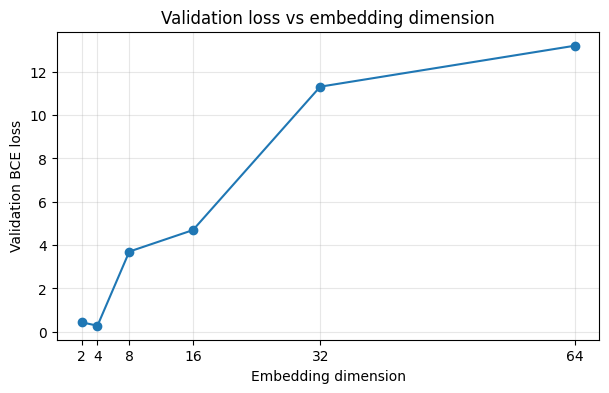

In [46]:
# Train/validation split over node pairs and dimension sweep

import matplotlib.pyplot as plt

split_seed = 42
train_fraction = 0.8
steps = 10_000
dims_to_test = [2, 4, 8, 16, 32, 64]

# Random split of pair indices
n_samples = target.shape[0]
g = torch.Generator().manual_seed(split_seed)
perm = torch.randperm(n_samples, generator=g)
train_size = int(train_fraction * n_samples)
train_idx = perm[:train_size]
val_idx = perm[train_size:]

print(f'Train pairs: {train_idx.numel()} | Validation pairs: {val_idx.numel()}')

results = []

for dim in dims_to_test:
    torch.manual_seed(0)

    model_dim = Shallow(n_nodes, dim)
    optimizer_dim = torch.optim.Adam(model_dim.parameters(), lr=1e-2)
    criterion_dim = torch.nn.BCELoss()

    # Train only on training pairs
    for _ in tqdm(range(steps), desc=f'dim={dim}', leave=False):
        pred_train = model_dim(idx_all_pairs[0, train_idx], idx_all_pairs[1, train_idx])
        loss_train = criterion_dim(pred_train, target[train_idx])

        optimizer_dim.zero_grad()
        loss_train.backward()
        optimizer_dim.step()

    # Evaluate on train and validation splits
    with torch.no_grad():
        pred_train = model_dim(idx_all_pairs[0, train_idx], idx_all_pairs[1, train_idx])
        pred_val = model_dim(idx_all_pairs[0, val_idx], idx_all_pairs[1, val_idx])
        final_train_loss = criterion_dim(pred_train, target[train_idx]).item()
        final_val_loss = criterion_dim(pred_val, target[val_idx]).item()

    results.append((dim, final_train_loss, final_val_loss))

# Select optimal dimension by validation loss
best_dim, best_train_loss, best_val_loss = min(results, key=lambda x: x[2])

print('\nResults (embedding_dim, train_loss, val_loss):')
for dim, tr, va in results:
    print(f'{dim:>2d} -> train: {tr:.6f}, val: {va:.6f}')

print(f'\nBest embedding dimension by validation loss: {best_dim}')
print(f'Validation loss at best dim: {best_val_loss:.6f}')

# Plot validation loss per embedding dimension
dims = [r[0] for r in results]
val_losses = [r[2] for r in results]

plt.figure(figsize=(7, 4))
plt.plot(dims, val_losses, marker='o')
plt.xticks(dims)
plt.xlabel('Embedding dimension')
plt.ylabel('Validation BCE loss')
plt.title('Validation loss vs embedding dimension')
plt.grid(True, alpha=0.3)
plt.show()

### Notes on overfitting and model selection

- The very low training loss for larger embedding dimensions means the model has enough capacity to fit (or memorize) the training pairs.
- The increase in validation loss as embedding dimension grows indicates poorer generalization, i.e. overfitting.
- Therefore, model selection should be based on **validation loss** (or another validation metric), not training loss.
- In this run, the best embedding dimension is the one with the minimum validation BCE loss (dim = 4).
- A practical improvement is to use **early stopping** on validation loss and average results across multiple random train/validation splits.

### Final optimized model (fixed dim = 4) + export `link_probabilities.pt`

This run fixes the embedding dimension to **4** (best from validation) and applies practical optimization tweaks:
- mini-batch training on the training split,
- AdamW with small weight decay,
- learning-rate scheduling on validation loss,
- gradient clipping,
- early stopping with best-checkpoint restore.

Then it saves final predicted link probabilities for all node pairs to `link_probabilities.pt`.

In [47]:
# Final model optimization with fixed embedding_dim=4 and save predictions

import copy

# Reproducible split
split_seed = 42
train_fraction = 0.8
g = torch.Generator().manual_seed(split_seed)
perm = torch.randperm(target.shape[0], generator=g)
train_size = int(train_fraction * target.shape[0])
train_idx = perm[:train_size]
val_idx = perm[train_size:]

print(f'Train pairs: {train_idx.numel()} | Validation pairs: {val_idx.numel()}')

# Fixed best embedding dimension from validation study
best_dim = 4

# Optimization tweaks
max_epochs = 4000
batch_size = 4096
lr = 1e-2
weight_decay = 1e-4
patience = 400
min_delta = 1e-5

# Model, optimizer, scheduler, loss
torch.manual_seed(0)
final_model = Shallow(n_nodes, best_dim)
optimizer_final = torch.optim.AdamW(final_model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = torch.nn.BCELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode='min', factor=0.5, patience=80, min_lr=1e-5
)

best_val_loss = float('inf')
best_state = None
best_epoch = -1
epochs_no_improve = 0

for epoch in tqdm(range(max_epochs), desc='final dim=4 training'):
    final_model.train()

    # Shuffle train indices each epoch (mini-batch SGD)
    train_perm = train_idx[torch.randperm(train_idx.numel())]

    for start in range(0, train_perm.numel(), batch_size):
        batch = train_perm[start:start + batch_size]

        pred_train = final_model(idx_all_pairs[0, batch], idx_all_pairs[1, batch])
        loss_train = criterion(pred_train, target[batch])

        optimizer_final.zero_grad()
        loss_train.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        optimizer_final.step()

    # Validation loss at end of epoch
    final_model.eval()
    with torch.no_grad():
        pred_val = final_model(idx_all_pairs[0, val_idx], idx_all_pairs[1, val_idx])
        val_loss = criterion(pred_val, target[val_idx]).item()

    scheduler.step(val_loss)

    # Early stopping + best checkpoint
    if val_loss < (best_val_loss - min_delta):
        best_val_loss = val_loss
        best_state = copy.deepcopy(final_model.state_dict())
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        break

# Restore best checkpoint
final_model.load_state_dict(best_state)
final_model.eval()

# Compute final train/val losses of best checkpoint
with torch.no_grad():
    pred_train_best = final_model(idx_all_pairs[0, train_idx], idx_all_pairs[1, train_idx])
    pred_val_best = final_model(idx_all_pairs[0, val_idx], idx_all_pairs[1, val_idx])
    train_loss_best = criterion(pred_train_best, target[train_idx]).item()
    val_loss_best = criterion(pred_val_best, target[val_idx]).item()

# Final predicted link probabilities on all node pairs
with torch.no_grad():
    link_probabilities = final_model(idx_all_pairs[0], idx_all_pairs[1])

# Save predictions
torch.save(link_probabilities, 'link_probabilities.pt')

print(f'Fixed embedding dim: {best_dim}')
print(f'Best epoch: {best_epoch}')
print(f'Best train loss: {train_loss_best:.6f}')
print(f'Best val loss: {val_loss_best:.6f}')
print('Saved predictions to: link_probabilities.pt')
print('Tensor shape:', tuple(link_probabilities.shape))

Train pairs: 15920 | Validation pairs: 3980


final dim=4 training:  25%|██▍       | 989/4000 [00:03<00:09, 324.36it/s]

Fixed embedding dim: 4
Best epoch: 589
Best train loss: 0.226353
Best val loss: 0.275962
Saved predictions to: link_probabilities.pt
Tensor shape: (19900,)


(array([9355., 1695., 1007.,  680.,  536.,  433.,  381.,  321.,  329.,
         269.,  292.,  234.,  290.,  222.,  251.,  280.,  295.,  399.,
         507., 2124.]),
 array([1.26331272e-16, 5.00000007e-02, 1.00000001e-01, 1.50000006e-01,
        2.00000003e-01, 2.50000000e-01, 3.00000012e-01, 3.49999994e-01,
        4.00000006e-01, 4.50000018e-01, 5.00000000e-01, 5.50000012e-01,
        6.00000024e-01, 6.50000036e-01, 6.99999988e-01, 7.50000000e-01,
        8.00000012e-01, 8.50000024e-01, 9.00000036e-01, 9.49999988e-01,
        1.00000000e+00]),
 <BarContainer object of 20 artists>)

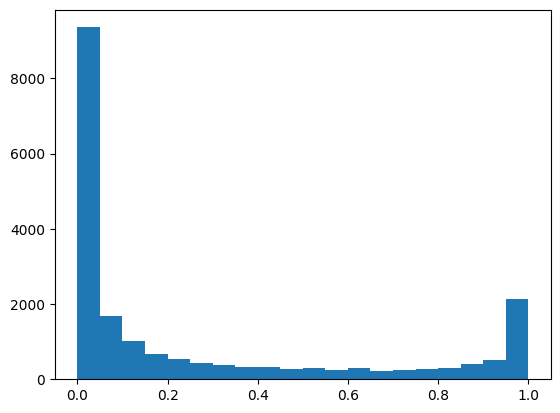

In [59]:
plt.hist(link_probabilities, bins=20)